In [55]:
# ============================================================
# Imports and configuration
# ============================================================
import sys
from pathlib import Path

# Ensure project root is on the path
notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.special import gamma as gamma_fn

from src.crack_growth_models import VariableStressParisErdogan
from src.predictive_models import CrackGrowthPredictor

# Matplotlib configuration
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

# Random seed for reproducibility
RNG = np.random.default_rng(42)

In [60]:
# ============================================================
# Dataset configuration
# ============================================================

# --- Time grid ---
T_MAX = 3.0          # Total time horizon (years)
N_T = 101             # Number of time points (100 intervals)
times = np.linspace(0.0, T_MAX, N_T)
dt = times[1] - times[0]
n_intervals = N_T - 1

# --- Dataset size ---
N_C = 20             # Number of components
N_S = 20             # Number of stress history replicates per component
N_TOTAL = N_C * N_S  # Total number of trajectories

# --- Paris law parameters ---
MU_LOGC = np.log(5e-14)   # Mean of ln C
STD_LOGC = 0.5             # Std of ln C (tunable)
MU_M = 3.2                 # Mean of m
STD_M = 0.1                # Std of m (tunable)

NAVG = 2.8e6               # Average cycles per year
A0 = 40.0                  # Initial crack length (mm)
A_CRIT = 155.0             # Critical crack length (mm)

# --- Load statistics distributions ---
# Mean stress range: Uniform(mu_low, mu_high)
MU_SIGMA_LOW = 8.0         # Lower bound on mean stress range (MPa)
MU_SIGMA_HIGH = 16.0       # Upper bound on mean stress range (MPa)

# Coefficient of variation: Uniform(cov_low, cov_high)
COV_LOW = 0.1              # Lower bound on CoV
COV_HIGH = 0.4             # Upper bound on CoV

print(f"Time grid:       {N_T} points over {T_MAX} years (dt = {dt:.3f} yr)")
print(f"Components:      {N_C}")
print(f"Histories/comp:  {N_S}")
print(f"Total trajectories:     {N_TOTAL}")

Time grid:       101 points over 3.0 years (dt = 0.030 yr)
Components:      20
Histories/comp:  20
Total trajectories:     400


In [61]:
# ============================================================
# Weibull moment matching
# ============================================================

def weibull_params_from_moments(mean: float, cov: float):
    """
    Compute Weibull scale and shape parameters from the mean
    and coefficient of variation (CoV) via moment matching.

    For a Weibull distribution with shape kappa and scale lambda:
        E[X]   = lambda * Gamma(1 + 1/kappa)
        Var[X] = lambda^2 * [Gamma(1 + 2/kappa) - Gamma(1 + 1/kappa)^2]

    Parameters
    ----------
    mean : float
        Desired mean of the distribution (MPa)
    cov : float
        Desired coefficient of variation (dimensionless)

    Returns
    -------
    lambda_ : float
        Weibull scale parameter
    kappa : float
        Weibull shape parameter
    """
    from scipy.optimize import brentq

    std = cov * mean

    # The CoV of a Weibull depends only on kappa, so solve for kappa first
    # CoV^2 = Gamma(1 + 2/kappa) / Gamma(1 + 1/kappa)^2 - 1
    def cov_residual(kappa):
        g1 = gamma_fn(1.0 + 1.0 / kappa)
        g2 = gamma_fn(1.0 + 2.0 / kappa)
        return np.sqrt(g2 / g1**2 - 1.0) - cov

    # kappa > 1 for unimodal Weibull; search in a broad range
    kappa = brentq(cov_residual, 0.5, 100.0)

    # Recover scale from the mean
    lambda_ = mean / gamma_fn(1.0 + 1.0 / kappa)

    return lambda_, kappa


# --- Quick sanity check ---
lam, kap = weibull_params_from_moments(mean=15.0, cov=0.2)
samples_check = RNG.weibull(kap, size=100_000) * lam
print(f"Target  : mean = {15.0:.3f}, CoV = {0.2:.3f}")
print(f"Recovered: mean = {np.mean(samples_check):.3f}, "
      f"CoV = {np.std(samples_check)/np.mean(samples_check):.3f}")

Target  : mean = 15.000, CoV = 0.200
Recovered: mean = 14.996, CoV = 0.199


In [62]:
# ============================================================
# Data generation
# ============================================================

# Output arrays
# Crack length trajectories: (N_TOTAL, N_T)
trajectories = np.zeros((N_TOTAL, N_T))

# Load statistics sequences: (N_TOTAL, n_intervals, 2)
# Last axis: [mean_stress, cov_stress]
load_stats = np.zeros((N_TOTAL, n_intervals, 2))

# Paris parameters, repeated N_S times per component: (N_TOTAL, 2)
# Last axis: [ln_C, m]
paris_params = np.zeros((N_TOTAL, 2))

# --- Outer loop: components ---
for j in range(N_C):

    # Sample Paris parameters for this component
    logc_j = RNG.normal(MU_LOGC, STD_LOGC)
    m_j    = RNG.normal(MU_M, STD_M)

    # --- Inner loop: stress history replicates ---
    for k in range(N_S):

        idx = j * N_S + k  # Flat trajectory index

        # Sample load statistics i.i.d. per interval
        mu_sigma = RNG.uniform(MU_SIGMA_LOW, MU_SIGMA_HIGH, size=n_intervals)
        cov_sigma = RNG.uniform(COV_LOW, COV_HIGH, size=n_intervals)

        # Draw one stress range realisation per interval via Weibull
        ds_array = np.zeros(n_intervals)
        for i in range(n_intervals):
            lam_i, kap_i = weibull_params_from_moments(mu_sigma[i], cov_sigma[i])
            ds_array[i] = RNG.weibull(kap_i) * lam_i

        # Integrate crack growth forward
        model = VariableStressParisErdogan(
            logc=logc_j,
            m=m_j,
            ds_array=ds_array,
            navg=NAVG,
            a0=A0,
            t=times
        )

        # Initialise trajectory
        a = np.zeros(N_T)
        a[0] = A0
        for i in range(1, N_T):
            a[i] = model.state_eq(a[i-1], times[i-1])

        # Store results
        trajectories[idx] = a
        load_stats[idx, :, 0] = mu_sigma
        load_stats[idx, :, 1] = cov_sigma
        paris_params[idx, 0] = logc_j
        paris_params[idx, 1] = m_j

print(f"trajectories : {trajectories.shape}")
print(f"load_stats   : {load_stats.shape}")
print(f"paris_params : {paris_params.shape}")

trajectories : (400, 101)
load_stats   : (400, 100, 2)
paris_params : (400, 2)


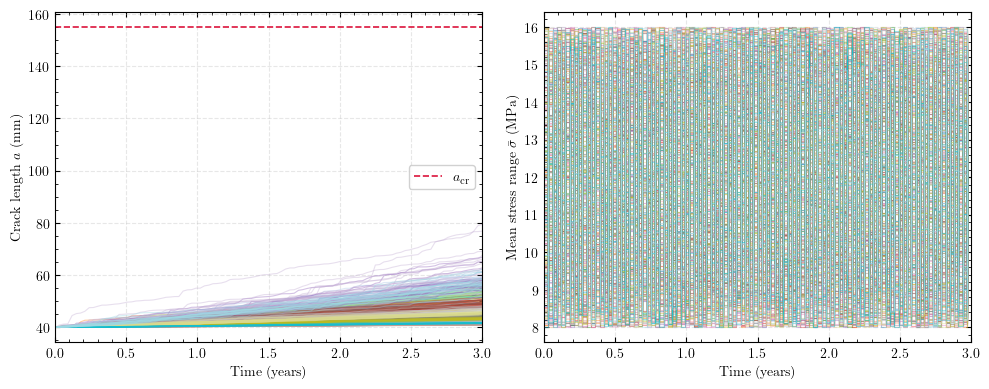

In [63]:
# ============================================================
# Visualisation of generated dataset
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cmap = plt.get_cmap('tab20')

# --- Left panel: crack growth trajectories ---
for idx in range(N_TOTAL):
    # Colour by component
    comp_idx = idx // N_S
    axes[0].plot(times, trajectories[idx],
                 color=cmap(comp_idx / N_C),
                 alpha=0.4, linewidth=0.8)

# Critical crack length
axes[0].axhline(A_CRIT, color='crimson', linestyle='--',
                linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
axes[0].set_xlabel(r'Time (years)')
axes[0].set_ylabel(r'Crack length $a$ (mm)')
axes[0].set_xlim(0, T_MAX)
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both', direction='in', top=True, right=True)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(frameon=True, framealpha=0.9)

# --- Right panel: mean stress range sequences ---
for idx in range(N_TOTAL):
    comp_idx = idx // N_S
    axes[1].step(times[:-1], load_stats[idx, :, 0],
                 where='post',
                 color=cmap(comp_idx / N_C),
                 alpha=0.4, linewidth=0.8)

axes[1].set_xlabel(r'Time (years)')
axes[1].set_ylabel(r'Mean stress range $\bar{\sigma}$ (MPa)')
axes[1].set_xlim(0, T_MAX)
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both', direction='in', top=True, right=True)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

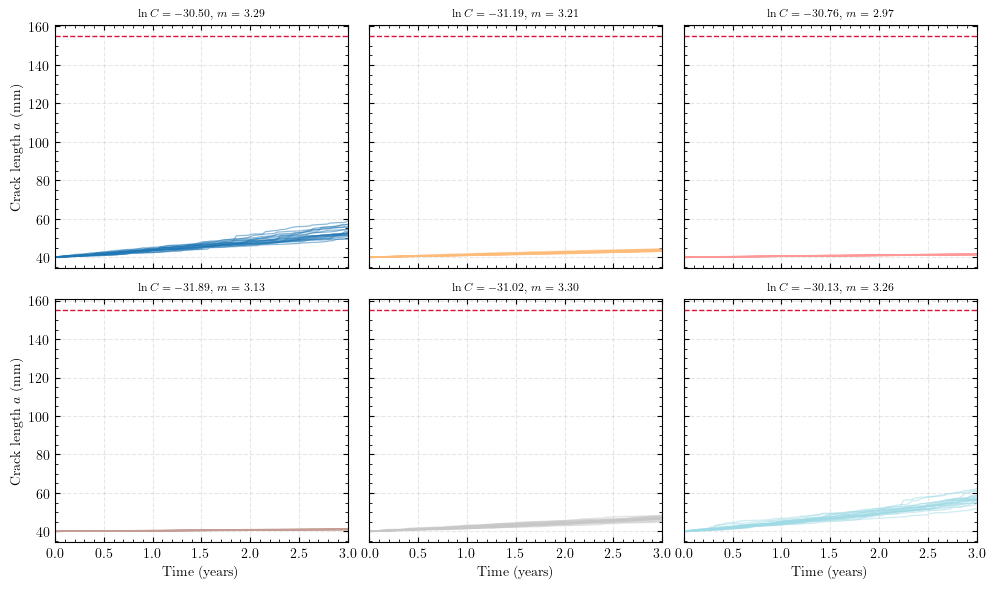

In [64]:
# ============================================================
# Visualisation: within- vs between-component variability
# ============================================================

# Select a subset of components to keep the plot legible
N_PLOT = min(6, N_C)
comp_indices = np.linspace(0, N_C - 1, N_PLOT, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
cmap = plt.get_cmap('tab20')

for plot_idx, comp_idx in enumerate(comp_indices):
    ax = axes[plot_idx]

    # Trajectory indices for this component
    traj_indices = np.arange(comp_idx * N_S, (comp_idx + 1) * N_S)

    for idx in traj_indices:
        ax.plot(times, trajectories[idx],
                color=cmap(comp_idx / N_C),
                alpha=0.5, linewidth=0.9)

    # Critical crack length
    ax.axhline(A_CRIT, color='crimson', linestyle='--',
               linewidth=1.0)

    # Annotate with Paris parameters (same for all replicates in component)
    logc_j = paris_params[comp_idx * N_S, 0]
    m_j    = paris_params[comp_idx * N_S, 1]
    ax.set_title(rf'$\ln C = {logc_j:.2f}$, $m = {m_j:.2f}$',
                 fontsize=8)

    ax.set_xlim(0, T_MAX)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.3)

    if plot_idx % 3 == 0:
        ax.set_ylabel(r'Crack length $a$ (mm)')
    if plot_idx >= 3:
        ax.set_xlabel(r'Time (years)')

#plt.suptitle('Within-component variability across stress history replicates',
#             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# Neural SDE architecture
# ============================================================
import jax
import jax.numpy as jnp
import equinox as eqx
from jax import vmap

class DriftNet(eqx.Module):
    """
    Neural network for the drift function g_theta.
    
    Inputs:  (u_t, mean_sigma, cov_sigma)
    Output:  scalar drift
    """
    layers: list

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(3, hidden_dim, key=keys[0]),
            eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1]),
            eqx.nn.Linear(hidden_dim, 1, key=keys[2]),
        ]

    def __call__(self, u_t, mean_sigma, cov_sigma):
        x = jnp.array([u_t, mean_sigma, cov_sigma])
        x = jnp.tanh(self.layers[0](x))
        x = jnp.tanh(self.layers[1](x))
        x = self.layers[2](x)
        return x.squeeze()


class DiffusionNet(eqx.Module):
    """
    Neural network for the diffusion function h_phi.

    Inputs:  (u_t, mean_sigma, cov_sigma)
    Output:  scalar non-negative diffusion coefficient
    """
    layers: list

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(3, hidden_dim, key=keys[0]),
            eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1]),
            eqx.nn.Linear(hidden_dim, 1, key=keys[2]),
        ]

    def __call__(self, u_t, mean_sigma, cov_sigma):
        x = jnp.array([u_t, mean_sigma, cov_sigma])
        x = jnp.tanh(self.layers[0](x))
        x = jnp.tanh(self.layers[1](x))
        x = jax.nn.softplus(self.layers[2](x))
        return x.squeeze()


class NeuralSDE(eqx.Module):
    """
    Neural SDE for crack growth rate dynamics.

    Models the log crack growth rate u_t = ln(lambda_t) as:
        du_t = g_theta(u_t, mean_sigma, cov_sigma) dt
                 + h_phi(u_t, mean_sigma, cov_sigma) dW_t

    Crack length is recovered by forward integration:
        a_{t+1} = a_t + exp(u_t) * dt
    """
    drift:     DriftNet
    diffusion: DiffusionNet

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        k1, k2 = jax.random.split(key)
        self.drift     = DriftNet(hidden_dim, k1)
        self.diffusion = DiffusionNet(hidden_dim, k2)

    def step(self, u_t, mean_sigma, cov_sigma, dt, key):
        """
        One Euler-Maruyama step for the log-rate process.

        Parameters
        ----------
        u_t        : float  — current log crack growth rate
        mean_sigma : float  — mean stress range for this interval
        cov_sigma  : float  — CoV of stress range for this interval
        dt         : float  — time step
        key        : PRNGKey

        Returns
        -------
        u_{t+1} : float
        """
        g = self.drift(u_t, mean_sigma, cov_sigma)
        h = self.diffusion(u_t, mean_sigma, cov_sigma)
        dW = jnp.sqrt(dt) * jax.random.normal(key)
        return u_t + g * dt + h * dW

    def simulate(self, a0, u0, load_stats, times, key):
        """
        Simulate a full crack growth trajectory.

        Parameters
        ----------
        a0         : float        — initial crack length (mm)
        u0         : float        — initial log crack growth rate
        load_stats : (n_intervals, 2) — mean and CoV per interval
        times      : (n_t,)       — time grid
        key        : PRNGKey

        Returns
        -------
        a : (n_t,)  — crack length trajectory
        u : (n_t,)  — log-rate trajectory
        """
        n_intervals = len(times) - 1
        keys = jax.random.split(key, n_intervals)

        a = jnp.zeros(len(times))
        u = jnp.zeros(len(times))
        a = a.at[0].set(a0)
        u = u.at[0].set(u0)

        for i in range(n_intervals):
            dt_i       = times[i+1] - times[i]
            mean_sigma = load_stats[i, 0]
            cov_sigma  = load_stats[i, 1]
            u_next     = self.step(u[i], mean_sigma, cov_sigma, dt_i, keys[i])
            a_next     = a[i] + jnp.exp(u[i]) * dt_i
            u = u.at[i+1].set(u_next)
            a = a.at[i+1].set(a_next)

        return a, u


# --- Initialise model ---
HIDDEN_DIM = 32
key_model = jax.random.PRNGKey(0)
model = NeuralSDE(hidden_dim=HIDDEN_DIM, key=key_model)

print(f"DriftNet     parameters: "
      f"{sum(x.size for x in jax.tree_util.tree_leaves(model.drift))}")
print(f"DiffusionNet parameters: "
      f"{sum(x.size for x in jax.tree_util.tree_leaves(model.diffusion))}")

DriftNet     parameters: 1217
DiffusionNet parameters: 1217


In [66]:
# ============================================================
# Training data preparation
# ============================================================

# Finite difference approximation of crack growth rates
# da/dt ~ (a_{i+1} - a_i) / dt, then take log
# Shape: (N_TOTAL, n_intervals)
delta_a = np.diff(trajectories, axis=1)          # (N_TOTAL, n_intervals)
delta_t = np.diff(times)                          # (n_intervals,)
rates   = delta_a / delta_t[np.newaxis, :]        # (N_TOTAL, n_intervals)

# Clip rates to avoid log(0) or log(negative) from numerical noise
rates   = np.clip(rates, a_min=1e-8, a_max=None)
log_rates = np.log(rates)                         # (N_TOTAL, n_intervals)

# Convert to JAX arrays
trajectories_jax = jnp.array(trajectories)       # (N_TOTAL, N_T)
log_rates_jax    = jnp.array(log_rates)           # (N_TOTAL, n_intervals)
load_stats_jax   = jnp.array(load_stats)          # (N_TOTAL, n_intervals, 2)
times_jax        = jnp.array(times)               # (N_T,)

# Quick sanity check on log-rate distribution
print(f"Log-rate range : [{log_rates.min():.2f}, {log_rates.max():.2f}]")
print(f"Log-rate mean  : {log_rates.mean():.2f}")
print(f"Log-rate std   : {log_rates.std():.2f}")

Log-rate range : [-18.42, 5.13]
Log-rate mean  : 0.13
Log-rate std   : 1.45


In [67]:
# ============================================================
# Combined loss: SDE log-likelihood + crack length reconstruction
# ============================================================

import optax

LR = 1e-4      # Learning rate for optimizer
ALPHA = 1e-2  # Weighting factor for crack length loss (tunable)

def loss_single(model, trajectory, log_rates, load_stats, times):
    """
    Combined loss for a single trajectory:
        L = L_SDE + alpha * L_crack

    Parameters
    ----------
    model      : NeuralSDE
    trajectory : (N_T,)           — observed crack length trajectory
    log_rates  : (n_intervals,)   — finite difference log-rates
    load_stats : (n_intervals, 2) — mean and CoV per interval
    times      : (N_T,)           — time grid

    Returns
    -------
    loss : scalar
    """
    dt = jnp.diff(times)

    # --- SDE log-likelihood term (Euler-Maruyama) ---
    def scan_fn_sde(carry, inputs):
        u_i, u_next, mean_sigma, cov_sigma, dt_i = inputs

        g = model.drift(u_i, mean_sigma, cov_sigma)
        h = model.diffusion(u_i, mean_sigma, cov_sigma)

        mu_pred  = u_i + g * dt_i
        var_pred = h**2 * dt_i + 1e-6

        nll = 0.5 * jnp.log(2 * jnp.pi * var_pred)
        nll += 0.5 * (u_next - mu_pred)**2 / var_pred

        return carry, nll

    sde_inputs = (
        log_rates[:-1],       # u_i
        log_rates[1:],        # u_{i+1}
        load_stats[:-1, 0],   # mean_sigma
        load_stats[:-1, 1],   # cov_sigma
        dt[:-1]               # dt_i
    )
    _, nlls = jax.lax.scan(scan_fn_sde, None, sde_inputs)
    l_sde = jnp.sum(nlls)

# --- Crack length reconstruction term ---
    def scan_fn_crack(carry, inputs):
        a_pred, key = carry
        u_i, mean_sigma, cov_sigma, dt_i, a_obs = inputs

        key, subkey = jax.random.split(key)

        g  = model.drift(u_i, mean_sigma, cov_sigma)
        h  = model.diffusion(u_i, mean_sigma, cov_sigma)
        dW = jnp.sqrt(dt_i) * jax.random.normal(subkey)

        u_next = u_i + g * dt_i + h * dW
        a_next = a_pred + jnp.exp(u_next) * dt_i
        sq_err = (a_next - a_obs)**2

        return (a_next, key), sq_err

    crack_inputs = (
        log_rates[:-1],       # u_i
        load_stats[:-1, 0],   # mean_sigma
        load_stats[:-1, 1],   # cov_sigma
        dt[:-1],              # dt_i
        trajectory[2:]        # a_obs
    )

    # Initialise carry with both a0 and a key
    crack_key = jax.random.PRNGKey(0)
    init_carry = (trajectory[1], crack_key)

    _, sq_errors = jax.lax.scan(scan_fn_crack, init_carry, crack_inputs)
    l_crack = jnp.sum(sq_errors)

    return l_sde + ALPHA * l_crack


def loss_batch(model, trajectories, log_rates, load_stats, times):
    """
    Mean combined loss over a batch using vmap.
    """
    per_traj_loss = vmap(
        lambda tr, lr, ls: loss_single(model, tr, lr, ls, times)
    )(trajectories, log_rates, load_stats)
    return jnp.mean(per_traj_loss)


# --- Reinitialise model and optimiser ---
key_model    = jax.random.PRNGKey(0)
model        = NeuralSDE(hidden_dim=HIDDEN_DIM, key=key_model)
optimiser    = optax.adam(LR)
opt_state    = optimiser.init(eqx.filter(model, eqx.is_array))
loss_history = []


@jax.jit
def train_step(model, opt_state, trajectories, log_rates, load_stats, times):
    loss, grads = jax.value_and_grad(
        lambda m: loss_batch(m, trajectories, log_rates, load_stats, times)
    )(model)
    updates, opt_state = optimiser.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


# --- Quick loss check before training ---
loss_init = loss_batch(
    model,
    trajectories_jax[:5],
    log_rates_jax[:5],
    load_stats_jax[:5],
    times_jax
)
print(f"Initial combined loss (5 trajectories): {loss_init:.4f}")

Initial combined loss (5 trajectories): 4739.8276


In [68]:
# ============================================================
# Training loop
# ============================================================

N_EPOCHS   = 1500
BATCH_SIZE = 20
key_train  = jax.random.PRNGKey(2)

for epoch in range(N_EPOCHS):

    # Random mini-batch
    key_train, subkey = jax.random.split(key_train)
    batch_idx = jax.random.choice(
        subkey, N_TOTAL, shape=(BATCH_SIZE,), replace=False)

    model, opt_state, loss = train_step(
        model,
        opt_state,
        trajectories_jax[batch_idx],
        log_rates_jax[batch_idx],
        load_stats_jax[batch_idx],
        times_jax
    )

    loss_history.append(float(loss))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.4f}")

Epoch   50 | Loss: 3678.4204
Epoch  100 | Loss: 2484.8372
Epoch  150 | Loss: 2048.7388
Epoch  200 | Loss: 1593.2938
Epoch  250 | Loss: 1265.6337
Epoch  300 | Loss: 1123.7235
Epoch  350 | Loss: 1113.1005
Epoch  400 | Loss: 986.1068
Epoch  450 | Loss: 909.8658
Epoch  500 | Loss: 822.2504
Epoch  550 | Loss: 728.0037
Epoch  600 | Loss: 662.9532
Epoch  650 | Loss: 644.9756
Epoch  700 | Loss: 652.7101
Epoch  750 | Loss: 553.8344
Epoch  800 | Loss: 552.8088
Epoch  850 | Loss: 545.8300
Epoch  900 | Loss: 485.5928
Epoch  950 | Loss: 505.8744
Epoch 1000 | Loss: 429.9648
Epoch 1050 | Loss: 465.9159
Epoch 1100 | Loss: 406.7386
Epoch 1150 | Loss: 429.7325
Epoch 1200 | Loss: 397.6983
Epoch 1250 | Loss: 426.9741
Epoch 1300 | Loss: 359.4766
Epoch 1350 | Loss: 381.1624
Epoch 1400 | Loss: 343.1030
Epoch 1450 | Loss: 328.8360
Epoch 1500 | Loss: 337.7879


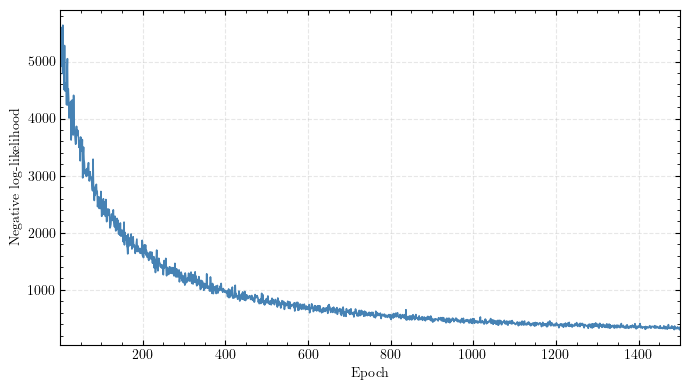

In [69]:
# ============================================================
# Loss curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(np.arange(1, len(loss_history) + 1), loss_history,
        color='steelblue', linewidth=1.2)

ax.set_xlabel(r'Epoch')
ax.set_ylabel(r'Negative log-likelihood')
ax.set_xlim(1, len(loss_history))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# Continue training for another 500 epochs
# ============================================================

N_EPOCHS_EXTRA = 500

for epoch in range(N_EPOCHS_EXTRA):

    key_train, subkey = jax.random.split(key_train)
    batch_idx = jax.random.choice(
        subkey, N_TOTAL, shape=(BATCH_SIZE,), replace=False)

    model, opt_state, loss = train_step(
        model,
        opt_state,
        trajectories_jax[batch_idx],
        log_rates_jax[batch_idx],
        load_stats_jax[batch_idx],
        times_jax
    )

    loss_history.append(float(loss))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {len(loss_history):4d} | Loss: {loss:.4f}")

Epoch 1550 | Loss: 335.8926
Epoch 1600 | Loss: 324.6963
Epoch 1650 | Loss: 308.4118
Epoch 1700 | Loss: 308.6654
Epoch 1750 | Loss: 314.9962
Epoch 1800 | Loss: 274.4328
Epoch 1850 | Loss: 303.7454
Epoch 1900 | Loss: 298.0470
Epoch 1950 | Loss: 296.3989
Epoch 2000 | Loss: 271.4230


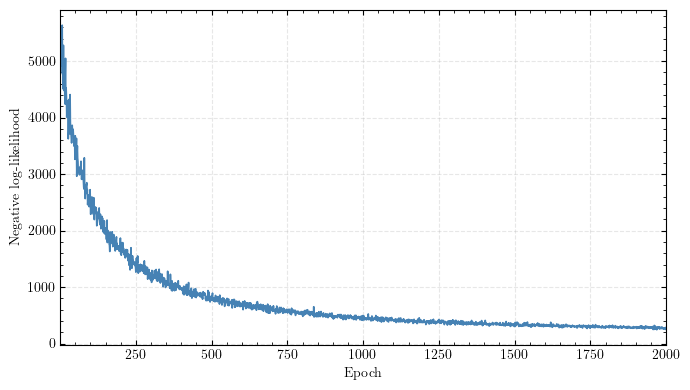

In [71]:
# ============================================================
# Loss curve
# ============================================================

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(np.arange(1, len(loss_history) + 1), loss_history,
        color='steelblue', linewidth=1.2)

ax.set_xlabel(r'Epoch')
ax.set_ylabel(r'Negative log-likelihood')
ax.set_xlim(1, len(loss_history))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Initial log-rate statistics:
  mean : -0.032
  std  : 1.464
  min  : -8.970
  max  : 3.429
  median: -0.014


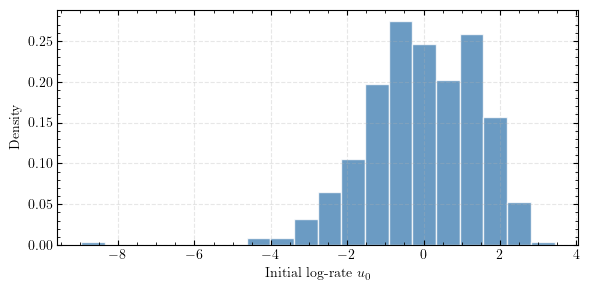

In [72]:
# ============================================================
# Distribution of initial log-rates in training data
# ============================================================

initial_log_rates = log_rates[:, 0]

print(f"Initial log-rate statistics:")
print(f"  mean : {initial_log_rates.mean():.3f}")
print(f"  std  : {initial_log_rates.std():.3f}")
print(f"  min  : {initial_log_rates.min():.3f}")
print(f"  max  : {initial_log_rates.max():.3f}")
print(f"  median: {np.median(initial_log_rates):.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(initial_log_rates, bins=20, color='steelblue',
        edgecolor='white', alpha=0.8, density=True)
ax.set_xlabel(r'Initial log-rate $u_0$')
ax.set_ylabel(r'Density')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# Revised trajectory generation with median u0
# ============================================================

U0 = float(np.median(initial_log_rates))
# U0 = 0.01
print(f"Initial log-rate u0 = {U0:.3f} "
      f"(initial rate ~ {np.exp(U0):.3f} mm/year)")

N_SAMPLES  = 400
key_eval   = jax.random.PRNGKey(3)

generated_trajectories = np.zeros((N_SAMPLES, N_T))
generated_log_rates    = np.zeros((N_SAMPLES, N_T))

for s in range(N_SAMPLES):
    key_eval, subkey = jax.random.split(key_eval)

    # Sample load statistics i.i.d. per interval
    mu_sigma  = RNG.uniform(MU_SIGMA_LOW, MU_SIGMA_HIGH, size=n_intervals)
    cov_sigma = RNG.uniform(COV_LOW, COV_HIGH, size=n_intervals)
    ls        = jnp.array(np.stack([mu_sigma, cov_sigma], axis=1))

    a, u = model.simulate(
        a0=A0,
        u0=U0,
        load_stats=ls,
        times=times_jax,
        key=subkey
    )

    generated_trajectories[s] = np.array(a)
    generated_log_rates[s]    = np.array(u)

print(f"Final crack length -- "
      f"mean: {generated_trajectories[:, -1].mean():.2f} mm, "
      f"std:  {generated_trajectories[:, -1].std():.2f} mm")
print(f"Training  trajectories -- "
      f"mean: {trajectories[:, -1].mean():.2f} mm, "
      f"std:  {trajectories[:, -1].std():.2f} mm")

Initial log-rate u0 = -0.014 (initial rate ~ 0.986 mm/year)
Final crack length -- mean: 55.11 mm, std:  43.63 mm
Training  trajectories -- mean: 48.36 mm, std:  6.72 mm


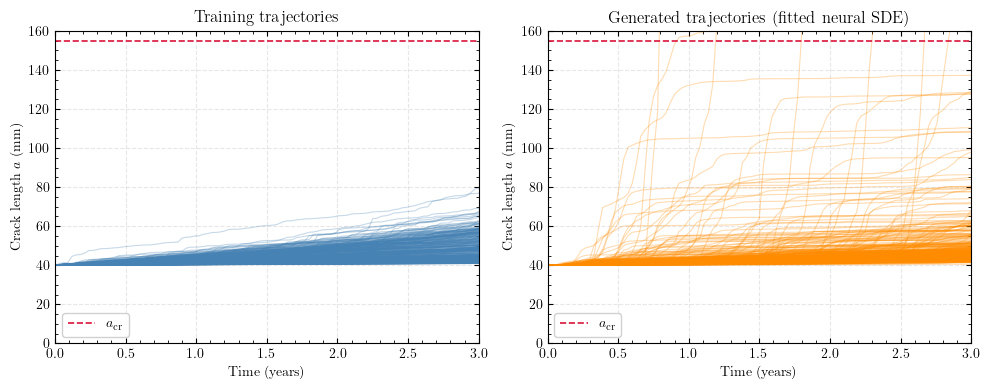

In [74]:
# ============================================================
# Visual comparison: generated vs training trajectories
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: training trajectories ---
for idx in range(N_TOTAL):
    axes[0].plot(times, trajectories[idx],
                 color='steelblue', alpha=0.3, linewidth=0.8)
axes[0].axhline(A_CRIT, color='crimson', linestyle='--',
                linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
axes[0].set_title('Training trajectories')
axes[0].set_xlabel(r'Time (years)')
axes[0].set_ylabel(r'Crack length $a$ (mm)')
axes[0].set_xlim(0, T_MAX)
axes[0].set_ylim(0, 160)
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both', direction='in', top=True, right=True)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(frameon=True, framealpha=0.9)

# --- Right: generated trajectories ---
for s in range(N_SAMPLES):
    axes[1].plot(times, generated_trajectories[s],
                 color='darkorange', alpha=0.3, linewidth=0.8)
axes[1].axhline(A_CRIT, color='crimson', linestyle='--',
                linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
axes[1].set_title('Generated trajectories (fitted neural SDE)')
axes[1].set_xlabel(r'Time (years)')
axes[1].set_ylabel(r'Crack length $a$ (mm)')
axes[1].set_xlim(0, T_MAX)
axes[1].set_ylim(0, 160)
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both', direction='in', top=True, right=True)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

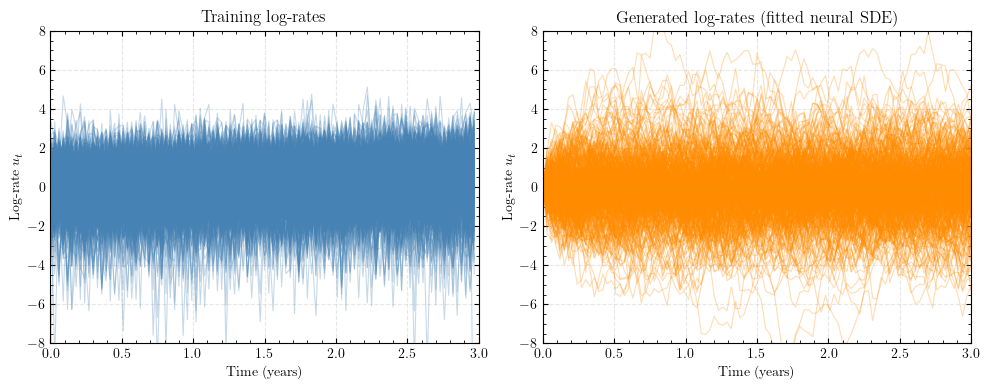

In [75]:
# ============================================================
# Diagnose: generated vs training log-rate trajectories
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: training log-rates ---
for idx in range(N_TOTAL):
    axes[0].plot(times[:-1], log_rates[idx],
                 color='steelblue', alpha=0.3, linewidth=0.8)
axes[0].set_title('Training log-rates')
axes[0].set_xlabel(r'Time (years)')
axes[0].set_ylabel(r'Log-rate $u_t$')
axes[0].set_xlim(0, T_MAX)
axes[0].set_ylim(-8, 8)
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both', direction='in', top=True, right=True)
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- Right: generated log-rates ---
for s in range(N_SAMPLES):
    axes[1].plot(times, generated_log_rates[s],
                 color='darkorange', alpha=0.3, linewidth=0.8)
axes[1].set_title('Generated log-rates (fitted neural SDE)')
axes[1].set_xlabel(r'Time (years)')
axes[1].set_ylabel(r'Log-rate $u_t$')
axes[1].set_xlim(0, T_MAX)
axes[1].set_ylim(-8, 8)
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both', direction='in', top=True, right=True)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Final crack length -- mean: 55.11 mm, std:  43.63 mm
Training trajectories -- mean: 48.36 mm, std:  6.72 mm


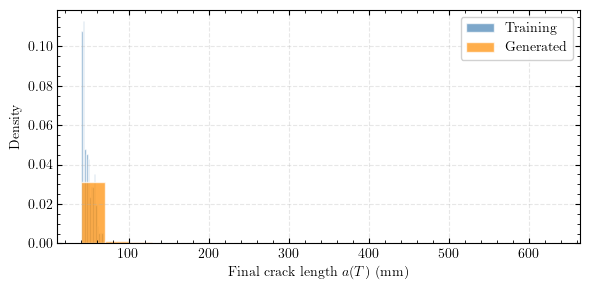

In [76]:
print(f"Final crack length -- "
      f"mean: {generated_trajectories[:, -1].mean():.2f} mm, "
      f"std:  {generated_trajectories[:, -1].std():.2f} mm")
print(f"Training trajectories -- "
      f"mean: {trajectories[:, -1].mean():.2f} mm, "
      f"std:  {trajectories[:, -1].std():.2f} mm")

# Distribution of final crack lengths
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(trajectories[:, -1], bins=20, color='steelblue',
        edgecolor='white', alpha=0.7, density=True, label='Training')
ax.hist(generated_trajectories[:, -1], bins=20, color='darkorange',
        edgecolor='white', alpha=0.7, density=True, label='Generated')
ax.set_xlabel(r'Final crack length $a(T)$ (mm)')
ax.set_ylabel(r'Density')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

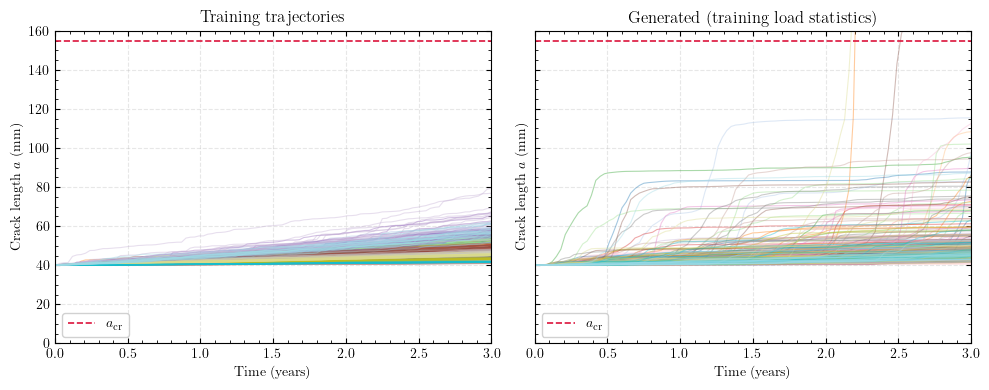

Generated (training LS) -- mean: 55.84 mm, std:  82.06 mm
Training               -- mean: 48.36 mm, std:  6.72 mm


In [77]:
# ============================================================
# Diagnostic: generate trajectories using training load statistics
# ============================================================

key_diag = jax.random.PRNGKey(4)

generated_diag = np.zeros((N_TOTAL, N_T))

for idx in range(N_TOTAL):
    key_diag, subkey = jax.random.split(key_diag)

    # Use exact load statistics from training trajectory idx
    ls = load_stats_jax[idx]

    a, u = model.simulate(
        a0=A0,
        u0=U0,
        load_stats=ls,
        times=times_jax,
        key=subkey
    )

    generated_diag[idx] = np.array(a)

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for idx in range(N_TOTAL):
    comp_idx = idx // N_S
    axes[0].plot(times, trajectories[idx],
                 color=cmap(comp_idx / N_C),
                 alpha=0.4, linewidth=0.8)
    axes[1].plot(times, generated_diag[idx],
                 color=cmap(comp_idx / N_C),
                 alpha=0.4, linewidth=0.8)

for ax, title in zip(axes, ['Training trajectories',
                             'Generated (training load statistics)']):
    ax.axhline(A_CRIT, color='crimson', linestyle='--',
               linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
    ax.set_xlabel(r'Time (years)')
    ax.set_ylabel(r'Crack length $a$ (mm)')
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(0, 160)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(title)
    ax.legend(frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"Generated (training LS) -- "
      f"mean: {generated_diag[:, -1].mean():.2f} mm, "
      f"std:  {generated_diag[:, -1].std():.2f} mm")
print(f"Training               -- "
      f"mean: {trajectories[:, -1].mean():.2f} mm, "
      f"std:  {trajectories[:, -1].std():.2f} mm")

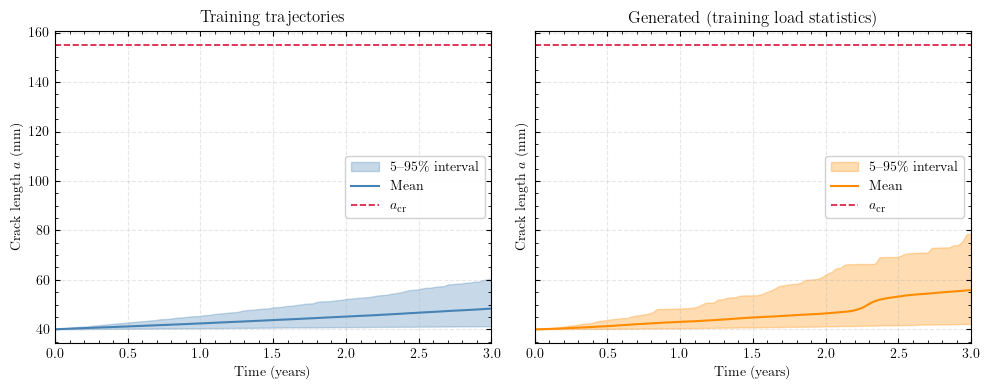

In [78]:
# ============================================================
# Statistical comparison: mean and credible interval
# ============================================================

# Compute percentiles
LOWER, UPPER = 5, 95

train_mean  = trajectories.mean(axis=0)
train_lower = np.percentile(trajectories, LOWER, axis=0)
train_upper = np.percentile(trajectories, UPPER, axis=0)

gen_mean    = generated_diag.mean(axis=0)
gen_lower   = np.percentile(generated_diag, LOWER, axis=0)
gen_upper   = np.percentile(generated_diag, UPPER, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, mean, lower, upper, title, color in zip(
    axes,
    [train_mean, gen_mean],
    [train_lower, gen_lower],
    [train_upper, gen_upper],
    ['Training trajectories', 'Generated (training load statistics)'],
    ['steelblue', 'darkorange']
):
    ax.fill_between(times, lower, upper,
                    color=color, alpha=0.3,
                    label=rf'{LOWER}--{UPPER}\% interval')
    ax.plot(times, mean, color=color, linewidth=1.5,
            label='Mean')
    ax.axhline(A_CRIT, color='crimson', linestyle='--',
               linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
    ax.set_title(title)
    ax.set_xlabel(r'Time (years)')
    ax.set_ylabel(r'Crack length $a$ (mm)')
    ax.set_xlim(0, T_MAX)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# Updated neural SDE architecture with autoregressive input
# ============================================================

class DriftNet(eqx.Module):
    """
    Neural network for the drift function g_theta.

    Inputs:  (u_t, a_t, mean_sigma, cov_sigma)
    Output:  scalar drift
    """
    layers: list

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(4, hidden_dim, key=keys[0]),  # 4 inputs now
            eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1]),
            eqx.nn.Linear(hidden_dim, 1, key=keys[2]),
        ]

    def __call__(self, u_t, a_t, mean_sigma, cov_sigma):
        x = jnp.array([u_t, a_t, mean_sigma, cov_sigma])
        x = jnp.tanh(self.layers[0](x))
        x = jnp.tanh(self.layers[1](x))
        x = self.layers[2](x)
        return x.squeeze()


class DiffusionNet(eqx.Module):
    """
    Neural network for the diffusion function h_phi.

    Inputs:  (u_t, a_t, mean_sigma, cov_sigma)
    Output:  scalar non-negative diffusion coefficient
    """
    layers: list

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(4, hidden_dim, key=keys[0]),  # 4 inputs now
            eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1]),
            eqx.nn.Linear(hidden_dim, 1, key=keys[2]),
        ]

    def __call__(self, u_t, a_t, mean_sigma, cov_sigma):
        x = jnp.array([u_t, a_t, mean_sigma, cov_sigma])
        x = jnp.tanh(self.layers[0](x))
        x = jnp.tanh(self.layers[1](x))
        x = jax.nn.softplus(self.layers[2](x))
        return x.squeeze()


class NeuralSDE(eqx.Module):
    drift:     DriftNet
    diffusion: DiffusionNet

    def __init__(self, hidden_dim: int, key: jax.random.PRNGKey):
        k1, k2 = jax.random.split(key)
        self.drift     = DriftNet(hidden_dim, k1)
        self.diffusion = DiffusionNet(hidden_dim, k2)

    def step(self, u_t, a_t, mean_sigma, cov_sigma, dt, key):
        """
        One Euler-Maruyama step.
        a_t is either teacher-forced (training) or predicted (simulation).
        """
        g  = self.drift(u_t, a_t, mean_sigma, cov_sigma)
        h  = self.diffusion(u_t, a_t, mean_sigma, cov_sigma)
        dW = jnp.sqrt(dt) * jax.random.normal(key)
        return u_t + g * dt + h * dW

    def simulate(self, a0, u0, load_stats, times, key):
        """
        Autoregressive simulation — a_t is always model-predicted.
        Only a0 is provided as a true observation.
        """
        n_intervals = len(times) - 1
        keys = jax.random.split(key, n_intervals)

        a = jnp.zeros(len(times))
        u = jnp.zeros(len(times))
        a = a.at[0].set(a0)
        u = u.at[0].set(u0)

        for i in range(n_intervals):
            dt_i       = times[i+1] - times[i]
            mean_sigma = load_stats[i, 0]
            cov_sigma  = load_stats[i, 1]

            # Use model-predicted a_t — not true crack length
            u_next = self.step(
                u[i], a[i], mean_sigma, cov_sigma, dt_i, keys[i])
            a_next = a[i] + jnp.exp(u[i]) * dt_i

            u = u.at[i+1].set(u_next)
            a = a.at[i+1].set(a_next)

        return a, u


# --- Initialise model ---
key_model = jax.random.PRNGKey(0)
model     = NeuralSDE(hidden_dim=HIDDEN_DIM, key=key_model)

print(f"DriftNet     parameters: "
      f"{sum(x.size for x in jax.tree_util.tree_leaves(model.drift))}")
print(f"DiffusionNet parameters: "
      f"{sum(x.size for x in jax.tree_util.tree_leaves(model.diffusion))}")

DriftNet     parameters: 1249
DiffusionNet parameters: 1249


In [88]:
# ============================================================
# Loss function with teacher forcing
# ============================================================
LR = 1e-4  # Learning rate for optimizer

def loss_single(model, trajectory, log_rates, load_stats, times):
    """
    Euler-Maruyama log-likelihood with teacher forcing.

    During training, the true crack length a_t is fed as input
    at each step — this is teacher forcing. The network never
    needs to roll out its own predictions during training.
    """
    dt = jnp.diff(times)

    def scan_fn(carry, inputs):
        # Unpack inputs — a_t is the TRUE crack length (teacher forcing)
        u_i, u_next, a_t, mean_sigma, cov_sigma, dt_i = inputs

        g = model.drift(u_i, a_t, mean_sigma, cov_sigma)
        h = model.diffusion(u_i, a_t, mean_sigma, cov_sigma)

        mu_pred  = u_i + g * dt_i
        var_pred = h**2 * dt_i + 1e-6

        nll  = 0.5 * jnp.log(2 * jnp.pi * var_pred)
        nll += 0.5 * (u_next - mu_pred)**2 / var_pred

        return carry, nll

    inputs = (
        log_rates[:-1],       # u_i
        log_rates[1:],        # u_{i+1}
        trajectory[:-2],      # a_t — true crack length (teacher forcing)
        load_stats[:-1, 0],   # mean_sigma
        load_stats[:-1, 1],   # cov_sigma
        dt[:-1]               # dt_i
    )

    _, nlls = jax.lax.scan(scan_fn, None, inputs)
    return jnp.sum(nlls)


def loss_batch(model, trajectories, log_rates, load_stats, times):
    per_traj_loss = vmap(
        lambda tr, lr, ls: loss_single(model, tr, lr, ls, times)
    )(trajectories, log_rates, load_stats)
    return jnp.mean(per_traj_loss)


# --- Reinitialise optimiser ---
optimiser    = optax.adam(LR)
opt_state    = optimiser.init(eqx.filter(model, eqx.is_array))
loss_history = []


@jax.jit
def train_step(model, opt_state, trajectories, log_rates, load_stats, times):
    loss, grads = jax.value_and_grad(
        lambda m: loss_batch(m, trajectories, log_rates, load_stats, times)
    )(model)
    updates, opt_state = optimiser.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


# --- Loss check ---
loss_init = loss_batch(
    model,
    trajectories_jax[:5],
    log_rates_jax[:5],
    load_stats_jax[:5],
    times_jax
)
print(f"Initial loss (5 trajectories): {loss_init:.4f}")

Initial loss (5 trajectories): 1437.7423


In [89]:
# ============================================================
# Training loop
# ============================================================

N_EPOCHS   = 1500
BATCH_SIZE = 20
key_train  = jax.random.PRNGKey(2)

for epoch in range(N_EPOCHS):

    key_train, subkey = jax.random.split(key_train)
    batch_idx = jax.random.choice(
        subkey, N_TOTAL, shape=(BATCH_SIZE,), replace=False)

    model, opt_state, loss = train_step(
        model,
        opt_state,
        trajectories_jax[batch_idx],
        log_rates_jax[batch_idx],
        load_stats_jax[batch_idx],
        times_jax
    )

    loss_history.append(float(loss))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.4f}")

Epoch  100 | Loss: 727.5812
Epoch  200 | Loss: 456.8092
Epoch  300 | Loss: 363.5088
Epoch  400 | Loss: 317.5250
Epoch  500 | Loss: 218.0521
Epoch  600 | Loss: 219.0518
Epoch  700 | Loss: 218.3537
Epoch  800 | Loss: 200.8329
Epoch  900 | Loss: 178.7369
Epoch 1000 | Loss: 156.3719
Epoch 1100 | Loss: 164.3633
Epoch 1200 | Loss: 138.7669
Epoch 1300 | Loss: 134.9118
Epoch 1400 | Loss: 135.0860
Epoch 1500 | Loss: 128.4880


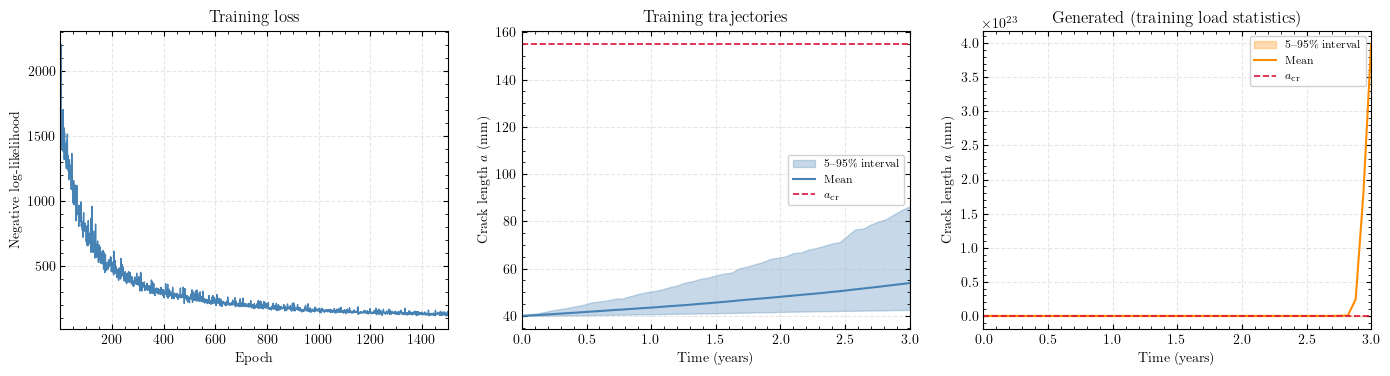

In [90]:
# ============================================================
# Loss curve and statistical comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Loss curve ---
axes[0].plot(np.arange(1, len(loss_history) + 1), loss_history,
             color='steelblue', linewidth=1.0)
axes[0].set_xlabel(r'Epoch')
axes[0].set_ylabel(r'Negative log-likelihood')
axes[0].set_xlim(1, len(loss_history))
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both', direction='in', top=True, right=True)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].set_title('Training loss')

# --- Compute statistics ---
LOWER, UPPER = 5, 95

train_mean  = trajectories.mean(axis=0)
train_lower = np.percentile(trajectories, LOWER, axis=0)
train_upper = np.percentile(trajectories, UPPER, axis=0)

gen_mean    = generated_diag.mean(axis=0)
gen_lower   = np.percentile(generated_diag, LOWER, axis=0)
gen_upper   = np.percentile(generated_diag, UPPER, axis=0)

# --- Mean and credible interval ---
for ax, mean, lower, upper, title, color in zip(
    axes[1:],
    [train_mean, gen_mean],
    [train_lower, gen_lower],
    [train_upper, gen_upper],
    ['Training trajectories',
     'Generated (training load statistics)'],
    ['steelblue', 'darkorange']
):
    ax.fill_between(times, lower, upper,
                    color=color, alpha=0.3,
                    label=rf'${LOWER}$--${UPPER}$\% interval')
    ax.plot(times, mean, color=color, linewidth=1.5,
            label='Mean')
    ax.axhline(A_CRIT, color='crimson', linestyle='--',
               linewidth=1.2, label=r'$a_{\mathrm{cr}}$')
    ax.set_title(title)
    ax.set_xlabel(r'Time (years)')
    ax.set_ylabel(r'Crack length $a$ (mm)')
    ax.set_xlim(0, T_MAX)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(frameon=True, framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# Regenerate diagnostic trajectories with autoregressive model
# ============================================================

key_diag = jax.random.PRNGKey(4)
generated_diag = np.zeros((N_TOTAL, N_T))

for idx in range(N_TOTAL):
    key_diag, subkey = jax.random.split(key_diag)

    ls = load_stats_jax[idx]

    a, u = model.simulate(
        a0=A0,
        u0=U0,
        load_stats=ls,
        times=times_jax,
        key=subkey
    )

    generated_diag[idx] = np.array(a)

print(f"Generated (training LS) -- "
      f"mean: {generated_diag[:, -1].mean():.2f} mm, "
      f"std:  {generated_diag[:, -1].std():.2f} mm")
print(f"Training               -- "
      f"mean: {trajectories[:, -1].mean():.2f} mm, "
      f"std:  {trajectories[:, -1].std():.2f} mm")

Generated (training LS) -- mean: 7534906.67 mm, std:  84792797.31 mm
Training               -- mean: 53.90 mm, std:  14.02 mm
